In [1]:
from collections import defaultdict
import requests
from bs4 import BeautifulSoup
import random
from classes import *

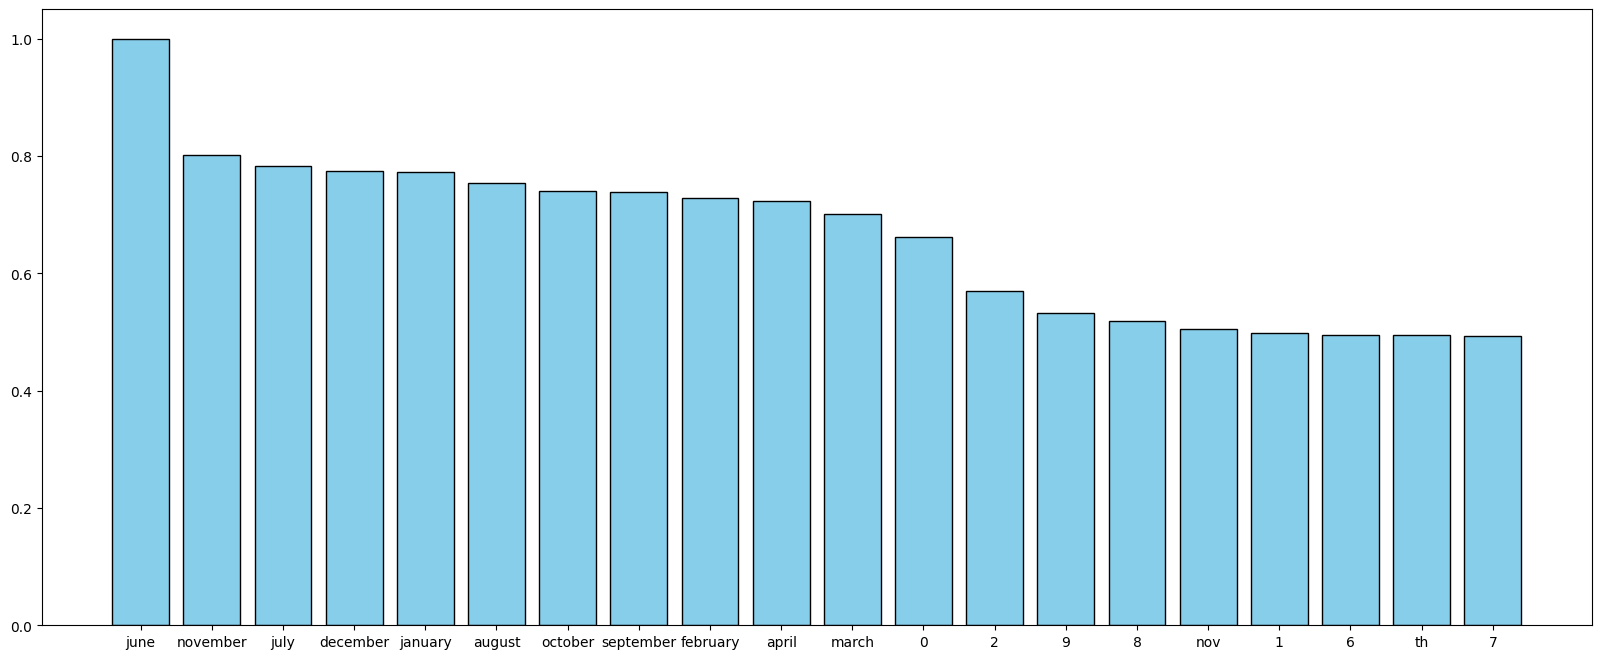

In [ ]:
db = CRVDatabase(filepath = 'wiki_scraper.crvdb')

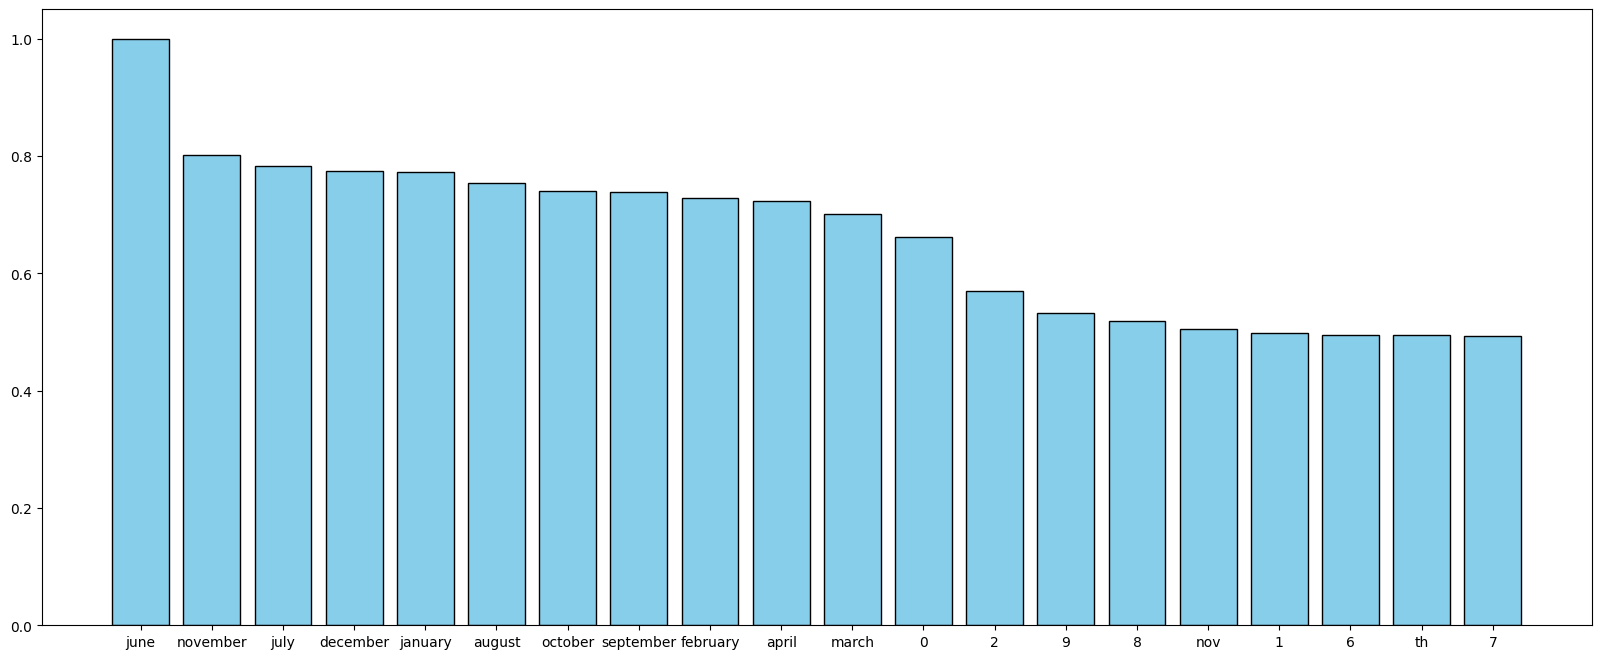

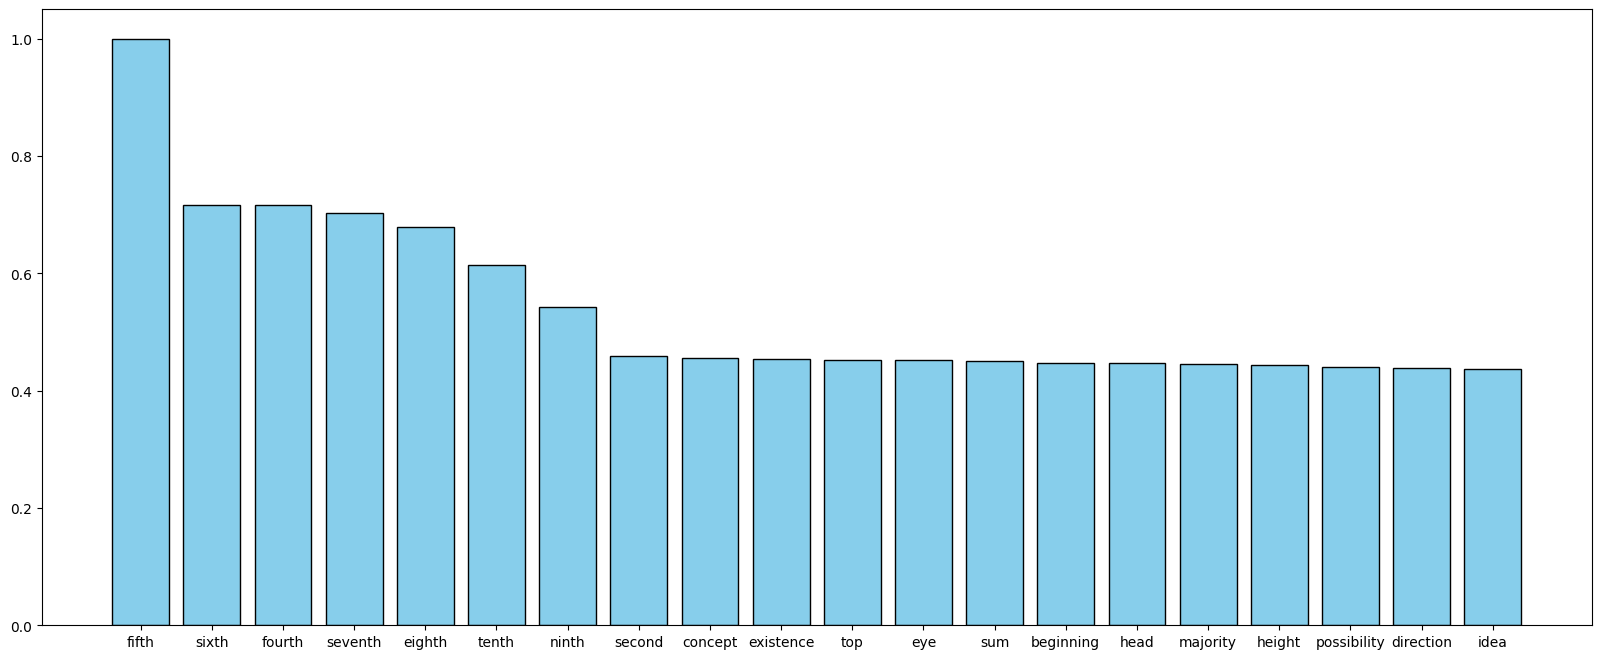

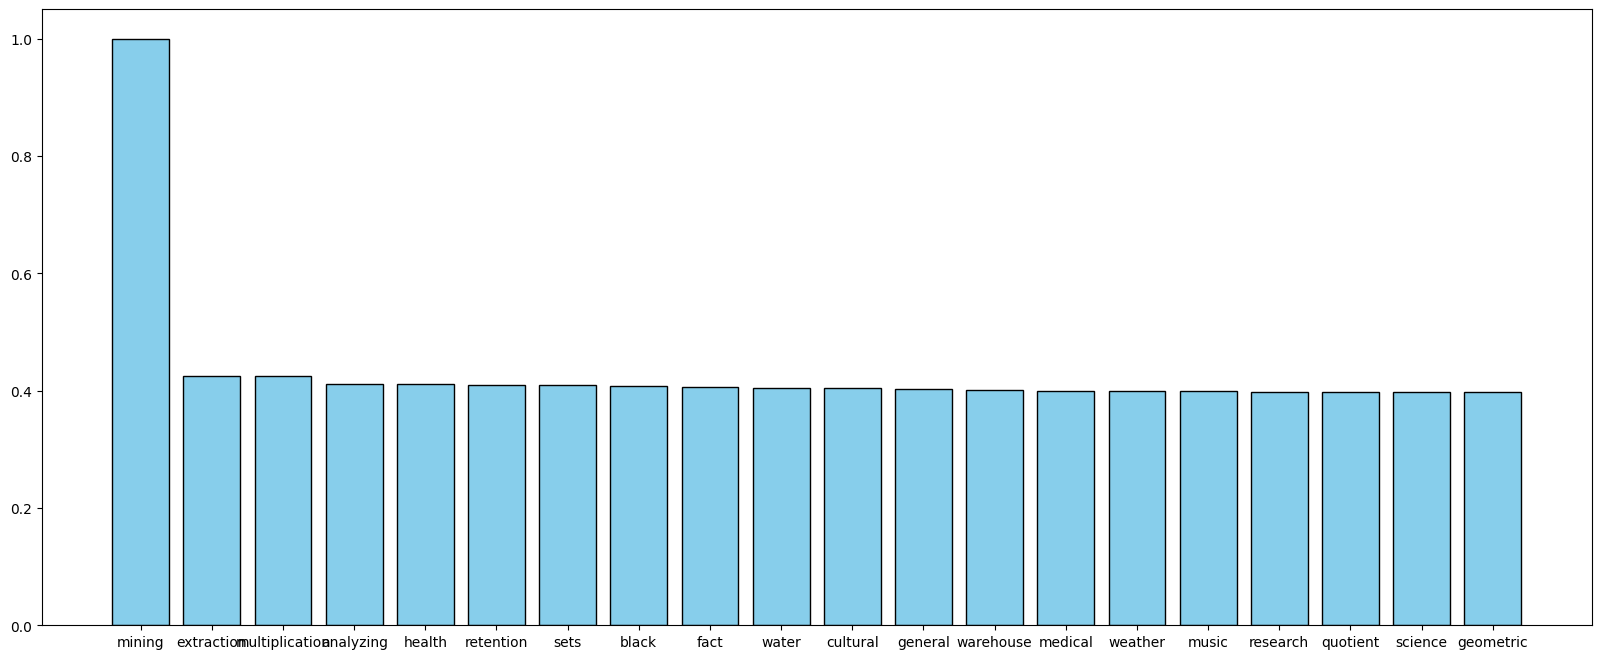

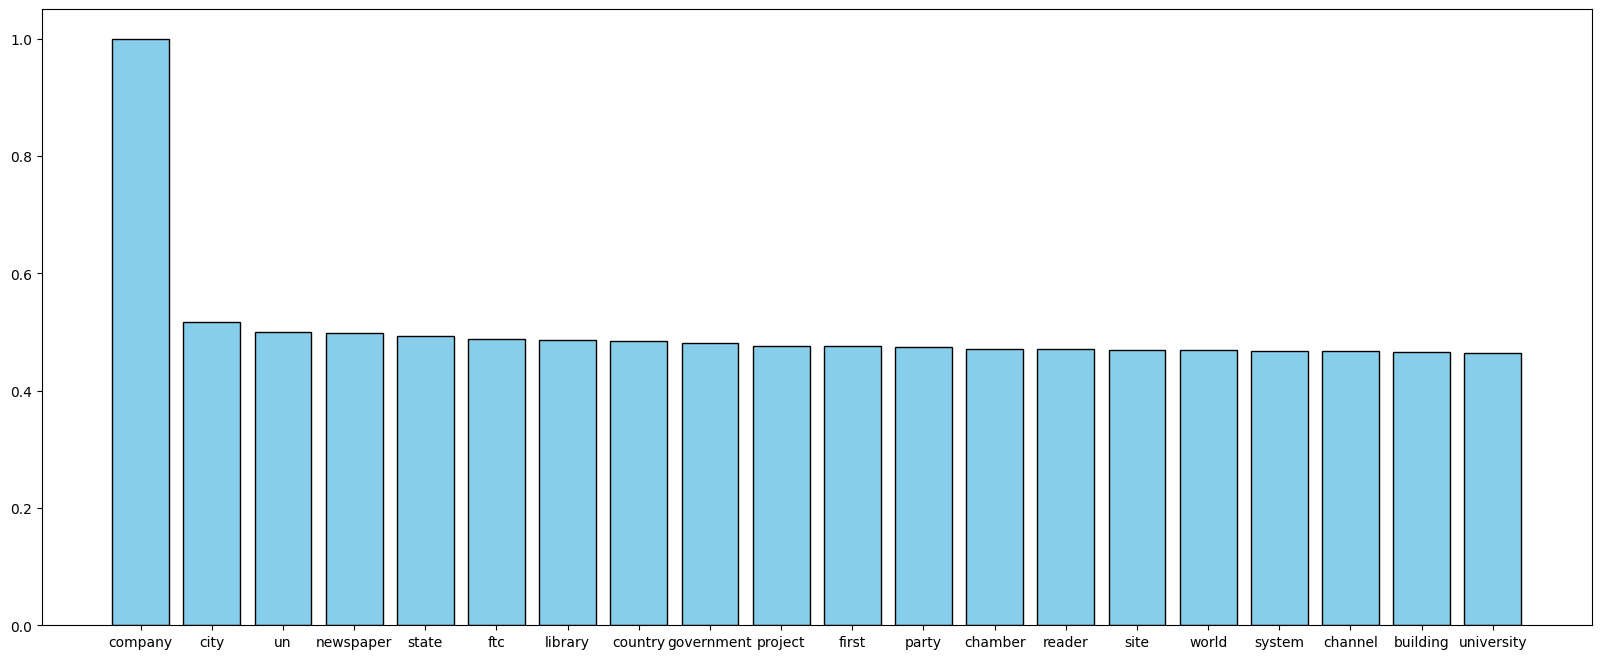

In [9]:
plot_dict(db.compare(db['june']))
plot_dict(db.compare(db['fifth']))
plot_dict(db.compare(db['mining']))
plot_dict(db.compare(db['company']))

In [3]:
raise Exception("don't run the below code for just testing out the crvdb file")

Exception: don't run the below code for just testing out the crvdb file

In [ ]:
counts = defaultdict(defaultdict)

In [ ]:
def load_text(text, window_size = 2):
    for window_center in range(len(text)):

        # the word that we will collect signatures for
        # around it
        center_word = text[window_center]

        for word_index in range(max(0, window_center - window_size), min(window_center + window_size + 1, len(text))):

            # while sliding the window, don't include the given word, which will always be in the center of the window
            if word_index == window_center:
                continue

            # add one to the count for that word's occurence next to the given word
            nearby_word = text[word_index]

            if center_word not in counts:
                counts[center_word] = defaultdict(int)
            counts[center_word][nearby_word] += 1


In [ ]:
#https://www.freecodecamp.org/news/scraping-wikipedia-articles-with-python/

from classes import split_sentence


def scrapeWikiArticle(url, max_articles = 100):

    for i in range(max_articles):

        response = requests.get(
            url=url,
            headers = {'User-Agent': 'my-app/0.0.1'}
        )

        soup = BeautifulSoup(response.content, 'html.parser')

        title = soup.find(id="firstHeading")
        texts = [item.getText() for item in list(soup.find_all('p'))]
        for text in texts:
            load_text(split_sentence(text.lower()))
        print(title.text)

        allLinks = list(soup.find(id="bodyContent").find_all("a"))
        random.shuffle(allLinks)
        linkToScrape = 0

        for link in allLinks:
            # We are only interested in other wiki articles
            try:
                if link['href'].find("/wiki/") == -1: 
                    continue
            except:
                continue

            # Use this link to scrape
            linkToScrape = link
            break

        url = "https://en.wikipedia.org" + linkToScrape['href']

for i in range(10):
    try:
        scrapeWikiArticle("https://en.wikipedia.org/wiki/Web_scraping")
    except Exception as e:
        pass

Web scraping
Data mining
Spiking neural network
ISSN
Power take-off
Flail mower
Drive shaft
Axle
Watt's linkage
Wheelbase
Electric generator
Recreational vehicle
Motorhome
File:17-GMC-Vandura-Chevrolet-G30-Daniela-Kloth-IMG 4026.JPG
Web scraping
JumpStation
W3Catalog
Search engine
Privacy concerns with Google
Googleshare
Talk:Googleshare
Help:Category
Help:Edit conflict
Help:Minor edit
Wikipedia:List of guidelines
Wikipedia:Reliable sources
Web scraping
Category:Web crawlers
StormCrawler
Wikipedia:Merging
Category:Wikipedia merging
Wikipedia:Categorization
Wikipedia:Five pillars
Wikipedia:Paid-contribution disclosure
Wikipedia:Civility
Wikipedia:Requests for oversight
URL
Digital object identifier
ISO 14031
ISO 6344
File:Question book-new.svg
Amber Diceless Roleplaying Game
List of The Chronicles of Amber characters
Blood of Amber
File:AliceCarryingFlamingoPurple.png
Faun & Games
Yon Ill Wind
Fantasy literature
Frank R. Stockton
Lewis Carroll Shelf Award
Ed Young (illustrator)
Category

In [ ]:
len(counts)

31422

In [ ]:
db = CRVDatabase(counts = counts)

In [ ]:
list(counts.keys())[0:10]

['<START>',
 'web',
 'scraping',
 ',',
 'harvesting',
 'or',
 'data',
 'extraction',
 'is',
 'used']

In [ ]:
db.save('wiki_scraper.crvdb')